In [1]:
#Vmin: 0.10 * Vmax (antatt)
#Tilsig: estimert fra magasinendring
#Begrensninger:
#    - Maks vannføring (Q_max)
#    - Magasinbegrensninger (Vmin, Vmax)
#    - Virkningsgrad
#    - Dysebegrensninger
#Optimalisering: B (med vannverdi)
#Nivå: Medium (nær avansert)

Antall timer: 8784
             Datetime  MWh  Price_ore_kWh  Power_W  Q_m3s
0 2024-01-01 00:00:00  0.0         33.227      0.0    0.0
1 2024-01-01 01:00:00  0.0         31.990      0.0    0.0
2 2024-01-01 02:00:00  0.0         29.967      0.0    0.0
3 2024-01-01 03:00:00  0.0         27.517      0.0    0.0
4 2024-01-01 04:00:00  0.0         26.988      0.0    0.0
Årlig tilsig: 29.6536 millioner m³/år
Gjennomsnittlig tilsig: 0.9377403359643794 m³/s
Min tilsig: 0.2767846475507766 m³/s
Max tilsig: 2.3065387295898048 m³/s
t=0, pris=33.23, valgt Q=10.700, P=60.05, eta=0.880, V etter valg=75561480.00
t=1, pris=31.99, valgt Q=10.700, P=60.05, eta=0.880, V etter valg=75523956.42
t=2, pris=29.97, valgt Q=10.700, P=60.05, eta=0.880, V etter valg=75486432.85
t=3, pris=27.52, valgt Q=10.700, P=60.05, eta=0.880, V etter valg=75448909.27
t=4, pris=26.99, valgt Q=10.700, P=60.05, eta=0.880, V etter valg=75411385.70

=== NØKKELTALL CASE 3 ===
Total energi: 161335.9 MWh
Total inntekt: 62,928,722 kr
Gj

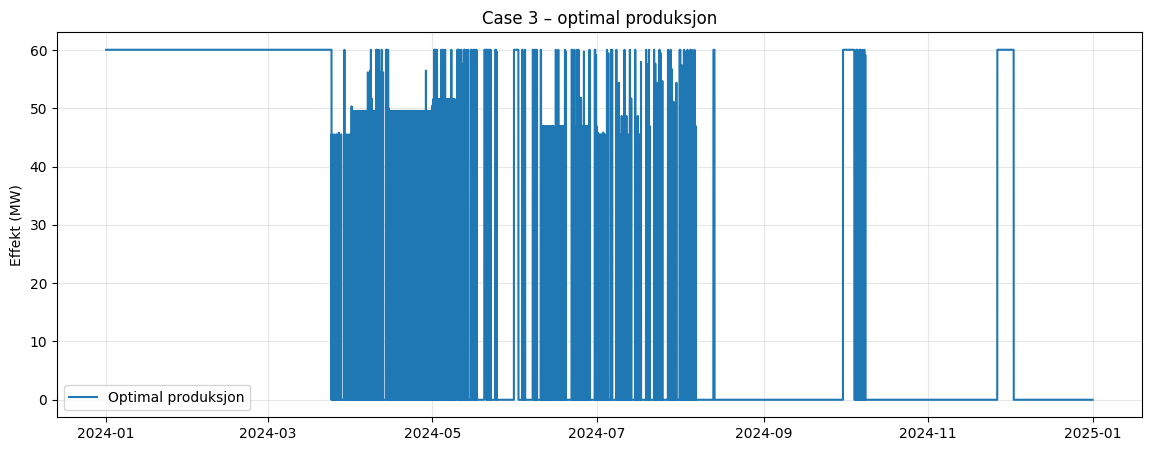

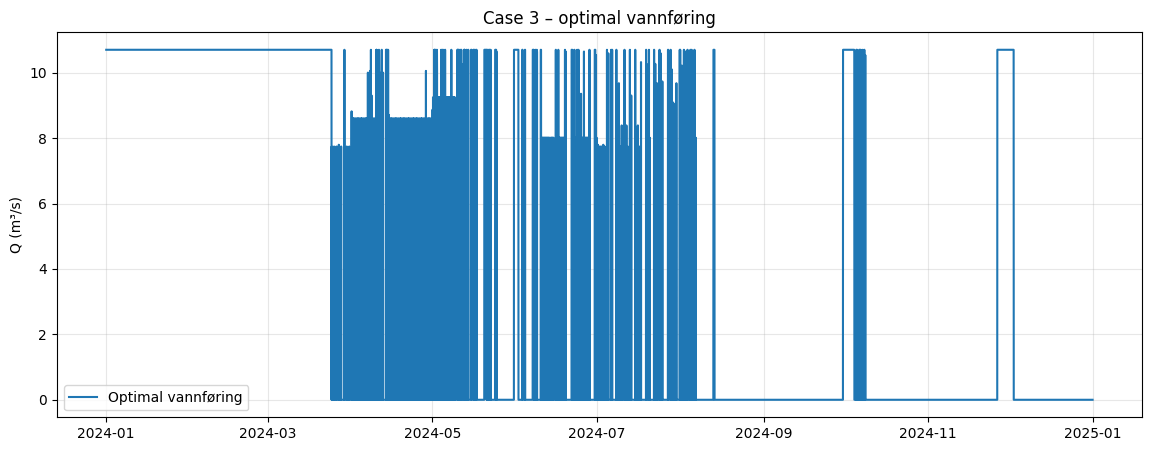

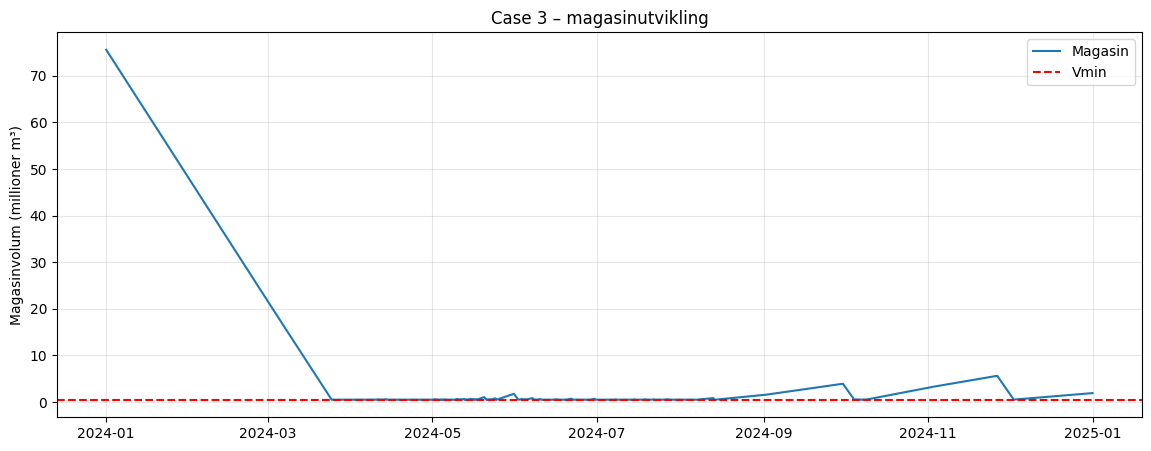

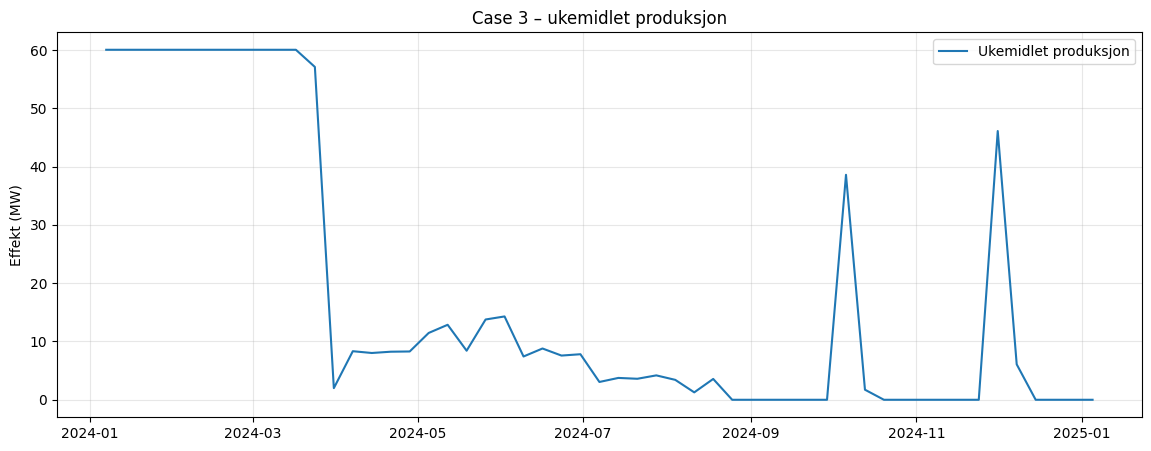

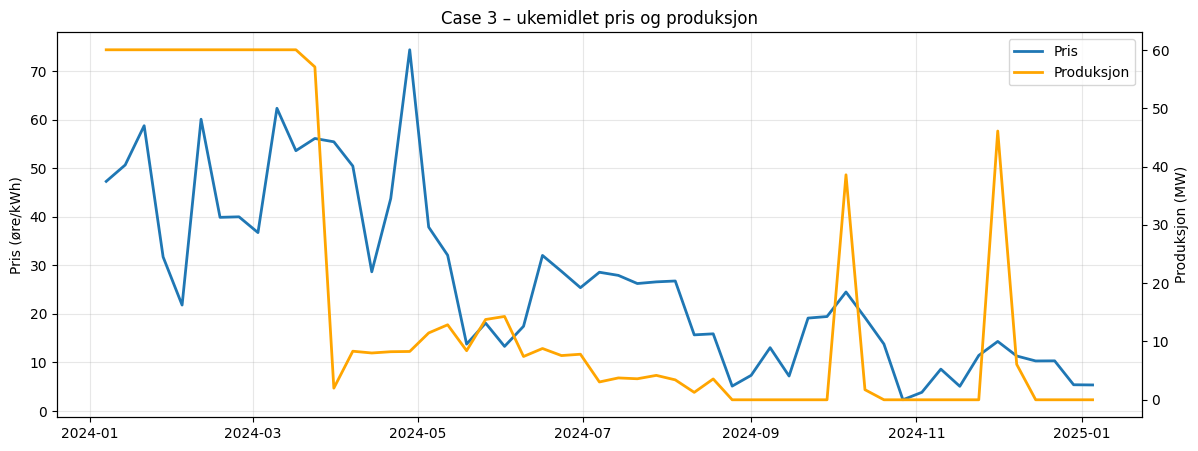

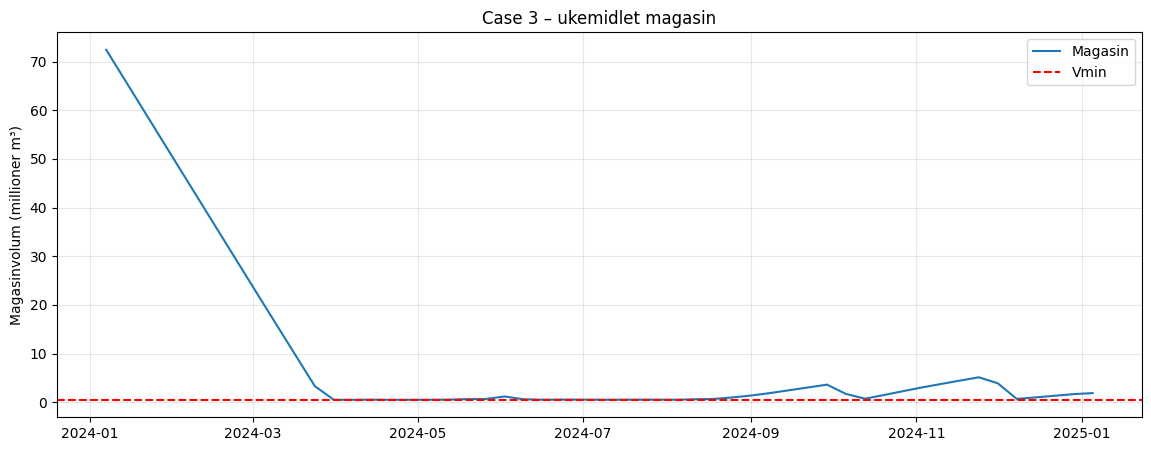

In [14]:
# Case 3: Prisoptimalisert drift (Realistisk)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CASE 3: REALISTISK OPTIMAL DRIFT
# ============================================================
# Hovedidé:
# For hver time tester vi ulike vannføringer og velger den som
# gir høyest inntekt, men bare innenfor realistiske begrensninger:
# - maks vannføring
# - magasin kan ikke gå under Vmin
# - netto fallhøyde avhenger av falltap
# - virkningsgrad avhenger av vannføring
#
# Viktig:
# Dette er IKKE Case 4 ennå, fordi vi ikke bruker vannverdi.
# Vi tenker altså kortsiktig: "Hva lønner seg denne timen?"
# ============================================================


# ============================================================
# 1) LAST FERDIG DATASETT
# ============================================================
# Antakelse:
# Vi bruker den ferdige fila dere allerede har laget, med
# produksjon, pris og beregnet vannføring.
# Her bruker vi prisserien som input til optimaliseringen.
# ============================================================

df = pd.read_excel("Sildvik_Produksjon_Pris_2024 (1).xlsx", engine="openpyxl")
df["Datetime"] = pd.to_datetime(df["Datetime"])

# Vi bruker pris som numpy-array for enklere looping
prices = df["Price_ore_kWh"].to_numpy()
times = df["Datetime"].to_numpy()

nT = len(df)

print("Antall timer:", nT)
print(df.head())


# ============================================================
# 2) MAGASIN OG TILSIG
# ============================================================
# Antakelse:
# Vi har ikke ekte timesoppløst tilsig.
# Derfor lager vi et enkelt estimat:
# - enten bruker vi en konstant tilsig-verdi
# - eller dere kan senere bytte dette ut med bedre data
#
# Her bruker vi en enkel konstant timesverdi som start.
# Denne må justeres når dere får bedre grunnlag.
# ============================================================

# Eksempelverdier for magasinvolum (V) og tilsig
Vmax = 94.5e6     # m^3  (hentet fra nordkraft.no)
Vmin = 0.5e6
V0 = 0.80 * Vmax  # startnivå: antatt 70 % fylt

# Estimert konstant tilsig per time

# ===========================================================================
# TILSIG BASERT PÅ ÅRSAVRENNING OG NEDSLAGSFELT
# ===========================================================================
# Har ikke målinger fra klubbvannet, så vi bruker NVE Atlas-data for å estimere tilsig.
#arsavrenning_mm = 1400          # mm/år, fra NVE Atlas
#nedslagsfelt_km2 = 101.5        # km²

#arsavrenning_m = arsavrenning_mm / 1000
#annual_inflow_m3 = arsavrenning_m * nedslagsfelt_km2 * 1e6

# ===========================================================================
# SESONGBASERT FORDELING AV TILSIG
# ===========================================================================
# Antakelse:
# Årlig tilsig fordeles på måneder med høyest tilsig i snøsmelting/sommer.
# Faktorene normaliseres slik at summen blir 1.

#monthly_factors = {
 #   1: 0.05, 2: 0.05, 3: 0.10, 4: 0.30,
  #  5: 1.80, 6: 2.00, 7: 1.40, 8: 0.80,
   # 9: 0.60, 10: 0.40, 11: 0.20, 12: 0.10
#}

#factor_sum = sum(monthly_factors.values())
#monthly_factors = {m: f / factor_sum for m, f in monthly_factors.items()}

# --------------------------------------------------
# TILSIG BASERT PÅ NVE REGINE
# --------------------------------------------------

# NVE + konstant elv
annual_inflow_m3 = 26.5e6 + 0.1 * 3600 * 8760  # m³/år fra NVE REGINE

fordelingsfaktorer = np.array([
    0.3, 0.3, 0.4, 1.5, 2.5, 1.4,
    0.7, 0.7, 1.0, 1.4, 1.2, 0.6
])

dager_per_maaned = np.array([31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
timer_per_maaned = dager_per_maaned * 24

# Fordel årsvolumet på måneder
maanedsvolum = annual_inflow_m3 * fordelingsfaktorer / fordelingsfaktorer.sum()

# m³/time per måned
tilsig_per_maaned_h = maanedsvolum / timer_per_maaned

# Timeserie med tilsig
inflow_hourly = np.repeat(tilsig_per_maaned_h, timer_per_maaned)

# Tilpass lengde til datasettet
inflow_hourly = inflow_hourly[:len(df)]

# m³/s kun for kontroll
inflow_m3_per_s = inflow_hourly / 3600

print("Årlig tilsig:", annual_inflow_m3 / 1e6, "millioner m³/år")
print("Gjennomsnittlig tilsig:", np.mean(inflow_m3_per_s), "m³/s")
print("Min tilsig:", np.min(inflow_m3_per_s), "m³/s")
print("Max tilsig:", np.max(inflow_m3_per_s), "m³/s")

# ============================================================
# 3) FYSISKE PARAMETERE
# ============================================================
# Her bruker vi tekniske data fra anlegget.
#
# Antakelser:
# - Brutto fallhøyde settes konstant
# - Falltap er basert på beregninger fra Excel-arket
# - For lave vannføringer (< 11 m^3/s) lar vi falltap følge en
#   kvadratisk sammenheng, slik at tapet går naturlig mot 0
# - For området der vi faktisk har beregnede data, bruker vi
#   direkte interpolasjon mellom punktene fra Excel
#
# Dette gjør modellen både fysisk rimelig og konsistent med
# de tekniske dataene dere har fått.
# ============================================================

rho = 1000        # kg/m^3
g = 9.81          # m/s^2
H_brutto = 655    # m
Q_max = 10.7      # m^3/s

# Falltap-punkter hentet fra teknisk Excel-ark
# Q [m^3/s]  ->  falltap [m]
Q_loss_points = np.array([11.0, 16.5, 22.0])
h_loss_points = np.array([5.2, 10.5, 14.3])

# Kvadratisk tilpasning for lave vannføringer
# Kalibrert slik at h_loss(11) = 5.2 m
k_loss = 5.2 / (11.0**2)

def h_loss(Q):
    """
    Beregner falltap som funksjon av vannføring.

    Antakelser:
    - For Q < 11 m^3/s brukes en kvadratisk sammenheng:
          h_loss = k * Q^2
      Dette gir fysisk riktig oppførsel ved lav vannføring.

    - For Q >= 11 m^3/s brukes lineær interpolasjon mellom
      beregnede punkter fra Excel-arket.

    Dermed bruker vi tekniske data direkte der vi har dem,
    men unngår urealistisk konstant falltap ved lav Q.
    """
    if np.isscalar(Q):
        if Q < 11.0:
            return k_loss * Q**2
        return np.interp(Q, Q_loss_points, h_loss_points)

    Q = np.asarray(Q)
    out = np.empty_like(Q, dtype=float)

    mask_low = Q < 11.0
    out[mask_low] = k_loss * Q[mask_low]**2
    out[~mask_low] = np.interp(Q[~mask_low], Q_loss_points, h_loss_points)

    return out

def H_netto(Q):
    """
    Netto fallhøyde = brutto fallhøyde - falltap
    """
    return H_brutto - h_loss(Q)


# ============================================================
# 4) VIRKNINGSGRADSMODELL
# ============================================================
# Antakelse:
# Virkningsgraden har en topp rundt et optimalt driftspunkt.
# Dette er ikke en eksakt turbinmodell, men en god teknisk
# tilnærming for å analysere drift.
# ============================================================

eta_max = 0.93

# Kan også endres på tall her om det dukker opp mer realistiske data senere
def eta_turbin(Q):
    if np.isscalar(Q):
        if Q <= 0:
            return 0.0

        q_rel = Q / Q_max

        if q_rel < 0.25:
            return 0.0
        elif q_rel < 0.50:
            # stigende del
            return 0.65 + (q_rel - 0.30) * (0.88 - 0.65) / (0.20)
        elif q_rel < 0.90:
            # bredt platå
            return 0.85 + 0.07 * (1 - ((q_rel - 0.70) / 0.20)**2)
        elif q_rel <= 1.00:
            # svak nedgang mot maks vannføring
            return 0.88

    Q = np.asarray(Q, dtype=float)
    out = np.zeros_like(Q, dtype=float)

    q_rel = Q / Q_max

    mask1 = (q_rel >= 0.30) & (q_rel < 0.50)
    out[mask1] = 0.65 + (q_rel[mask1] - 0.30) * (0.88 - 0.65) / (0.20)

    mask2 = (q_rel >= 0.60) & (q_rel < 0.90)
    out[mask2] = 0.88 + 0.04 * (1 - ((q_rel[mask2] - 0.75) / 0.15)**2)

    mask3 = (q_rel >= 0.90) & (q_rel <= 1.00)
    out[mask3] = 0.88 - (q_rel[mask3] - 0.90) * (0.88 - 0.80) / 0.10

    return out

# ============================================================
# 6) FUNKSJON FOR EFFEKT VED GITT VANNFØRING
# ============================================================
# Antakelse:
# Effekt bestemmes av:
# - vannføring
# - netto fallhøyde
# - virkningsgrad
# ============================================================

def power_MW(Q):
    Hn = H_netto(Q)
    eta = eta_turbin(Q)
    P = rho * g * Q * Hn * eta / 1e6
    return P, eta, Hn


# ============================================================
# 7) VALG AV DRIFTSPUNKT HVER TIME
# ============================================================
# Antakelse:
# For hver time tester vi flere mulige Q-verdier.
# Vi velger den Q som gir høyest inntekt denne timen,
# så lenge:
# - magasinet ikke går under Vmin
# - Q ikke overstiger Q_max
# - eventuell minimumseffekt overholdes
#
# Dette er realistisk drift med fysiske begrensninger,
# men uten vannverdi.
# ============================================================

# ============================================================
# CASE 3 - REALISTISK OPTIMAL DRIFT
# ============================================================
# Antakelser:
# - Drift optimaliseres time for time
# - Ingen vannverdi brukes i Case 3
# - Magasin kan ikke gå under Vmin
# - Vannføring kan ikke endres for raskt (ramping)
# - Vi tillater ikke veldig lav drift
# - Vi legger inn startkostnad for å unngå for hyppig av/på-drift
# ============================================================

Q_candidates = np.linspace(0, Q_max, 200)

Q_out = np.zeros(nT)
P_out = np.zeros(nT)
eta_out = np.zeros(nT)
Hn_out = np.zeros(nT)
revenue_out = np.zeros(nT)
V = np.zeros(nT)

V[0] = V0

# Valgte realistiske driftsgrenser for Case 3
max_delta_Q = 1.0         # m^3/s per time
Q_min = 5.0               # minste vannføring når anlegget først går
P_min = 45.0              # minste effekt når anlegget først går
# Kanskje spør om denne verdien? Hva er realistisk minimumseffekt for et anlegg av denne størrelsen?
startup_cost_ore = 1000000  # straff for oppstart. Verdi fra Matthew
ramp_penalty_coeff = 60000 # straff for raske endringer i Q.

for t in range(nT):

    # --------------------------------------------------------
    # 1) Oppdater magasin med tilsig
    # --------------------------------------------------------
    if t > 0:
        V[t] = V[t-1] + inflow_hourly[t]

    # Magasin kan ikke overstige Vmax
    if V[t] > Vmax:
        V[t] = Vmax

    # --------------------------------------------------------
    # 2) Initialiser beste løsning for denne timen
    # --------------------------------------------------------
    best_revenue = 0.0
    best_Q = 0.0
    best_P = 0.0
    best_eta = 0.0
    best_Hn = H_netto(0)

    # Forrige times vannføring brukes til ramping/startkostnad
    prev_Q = Q_out[t-1] if t > 0 else 0.0

    # --------------------------------------------------------
    # 3) Test alle kandidat-vannføringer
    # --------------------------------------------------------
    for Q in Q_candidates:

        water_use = Q * 3600  # m^3 brukt denne timen

        # Magasinet kan ikke tappes under minimumsnivå
        if V[t] - water_use < Vmin:
            continue

        # Ramping gjelder bare når anlegget allerede er i drift.
        # Vi tillater større sprang ved oppstart fra 0.
        if prev_Q > 0 and abs(Q - prev_Q) > max_delta_Q:
            continue

        # Hvis vi først produserer, skal vi ikke ligge på veldig lav vannføring
        if Q > 0 and Q < Q_min:
            continue

        # Beregn effekt, virkningsgrad og netto fallhøyde
        P, eta, Hn = power_MW(Q)

        # Hvis vi først produserer, skal vi ikke ligge på veldig lav effekt
        if Q > 0 and P < P_min:
            continue

        # Inntekt denne timen
        # Pris [øre/kWh] * 1000 kWh/MWh * P [MW] = øre per time
        revenue_raw = prices[t] * 1000 * P

        # Realistiske straffer
        ramp_penalty = ramp_penalty_coeff * abs(Q - prev_Q)
        startup_cost = startup_cost_ore if (prev_Q == 0.0 and Q > 0.0) else 0.0

        # CASE 3:
        # Ingen vannverdi og ingen water_cost her
        revenue = revenue_raw - ramp_penalty - startup_cost

        # Velg beste lovlige driftspunkt
        if revenue > best_revenue:
            best_revenue = revenue
            best_Q = Q
            best_P = P
            best_eta = eta
            best_Hn = Hn

    # --------------------------------------------------------
    # 4) Lagre valgt resultat
    # --------------------------------------------------------
    Q_out[t] = best_Q
    P_out[t] = best_P
    eta_out[t] = best_eta
    Hn_out[t] = best_Hn
    revenue_out[t] = best_revenue

    # --------------------------------------------------------
    # 5) Oppdater magasin etter valgt produksjon
    # --------------------------------------------------------
    V[t] -= best_Q * 3600

    if V[t] < Vmin:
        V[t] = Vmin

    # --------------------------------------------------------
    # 6) Debug-print for de første timene
    # --------------------------------------------------------
    if t < 5:
        print(f"t={t}, pris={prices[t]:.2f}, valgt Q={best_Q:.3f}, "
              f"P={best_P:.2f}, eta={best_eta:.3f}, V etter valg={V[t]:.2f}")


# ============================================================
# 8) RESULTATTABELL
# ============================================================

results = pd.DataFrame({
    "Datetime": times,
    "Price_ore_kWh": prices,
    "Q_opt_m3s": Q_out,
    "P_opt_MW": P_out,
    "eta_opt": eta_out,
    "H_netto_m": Hn_out,
    "Revenue_ore_per_h": revenue_out,
    "Magasin_m3": V
})

# --------------------------------------------------------
# Nøkkeltall for Case 3
# --------------------------------------------------------
total_energy_MWh = results["P_opt_MW"].sum()
total_revenue_NOK = results["Revenue_ore_per_h"].sum() / 100
avg_eta = results.loc[results["P_opt_MW"] > 0, "eta_opt"].mean()
drift_hours = (results["P_opt_MW"] > 0).sum()

starts = (
    (results["Q_opt_m3s"] > 0) &
    (results["Q_opt_m3s"].shift(1, fill_value=0) == 0)
).sum()

print("\n=== NØKKELTALL CASE 3 ===")
print(f"Total energi: {total_energy_MWh:.1f} MWh")
print(f"Total inntekt: {total_revenue_NOK:,.0f} kr")
print(f"Gjennomsnittlig virkningsgrad i drift: {avg_eta*100:.2f} %")
print(f"Driftstimer: {drift_hours}")
print(f"Antall oppstarter: {starts}")

print(results.head())
print(results.describe())

print(results[["Q_opt_m3s", "P_opt_MW"]].describe())
print(results[["Q_opt_m3s", "P_opt_MW"]].head(20))

# ============================================================
# 9) NØKKELTALL
# ============================================================

total_energy_MWh = results["P_opt_MW"].sum()     # 1 time per rad
total_revenue_NOK = results["Revenue_ore_per_h"].sum() / 100
avg_eta_weighted = (
    (results["eta_opt"] * results["P_opt_MW"]).sum() /
    results.loc[results["P_opt_MW"] > 0, "P_opt_MW"].sum()
)
drift_hours = (results["P_opt_MW"] > 0).sum()

print("\n=== NØKKELTALL CASE 3 ===")
print(f"Total energi: {total_energy_MWh:.1f} MWh")
print(f"Total inntekt: {total_revenue_NOK:,.0f} kr")
print(f"Gjennomsnittlig virkningsgrad i drift: {avg_eta_weighted*100:.2f} %")
print(f"Driftstimer: {drift_hours}")


# ============================================================
# 10) PLOTS
# ============================================================

# --------------------------------------------------
# PLOTS CASE 3 – SAMME STRUKTUR SOM CASE 1
# --------------------------------------------------

results["Datetime"] = pd.to_datetime(results["Datetime"])

# 1. Produksjon
plt.figure(figsize=(14, 5))
plt.plot(results["Datetime"], results["P_opt_MW"], label="Optimal produksjon")
plt.title("Case 3 – optimal produksjon")
plt.ylabel("Effekt (MW)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# 2. Vannføring
plt.figure(figsize=(14, 5))
plt.plot(results["Datetime"], results["Q_opt_m3s"], label="Optimal vannføring")
plt.title("Case 3 – optimal vannføring")
plt.ylabel("Q (m³/s)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# 3. Magasin
plt.figure(figsize=(14, 5))
plt.plot(results["Datetime"], results["Magasin_m3"] / 1e6, label="Magasin")
plt.axhline(Vmin / 1e6, color="red", linestyle="--", label="Vmin")
plt.title("Case 3 – magasinutvikling")
plt.ylabel("Magasinvolum (millioner m³)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# 4. Ukemidlet produksjon
results_plot = results.copy()
results_plot = results_plot.set_index("Datetime")
weekly = results_plot.resample("W").mean(numeric_only=True)

plt.figure(figsize=(14, 5))
plt.plot(weekly.index, weekly["P_opt_MW"], label="Ukemidlet produksjon")
plt.title("Case 3 – ukemidlet produksjon")
plt.ylabel("Effekt (MW)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# 5. Ukemidlet pris og produksjon
plt.figure(figsize=(14, 5))

ax1 = plt.gca()
ax1.plot(weekly.index, weekly["Price_ore_kWh"], label="Pris", linewidth=2)
ax1.set_ylabel("Pris (øre/kWh)")
ax1.set_title("Case 3 – ukemidlet pris og produksjon")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(weekly.index, weekly["P_opt_MW"], label="Produksjon", linewidth=2, color="orange")
ax2.set_ylabel("Produksjon (MW)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.show()


# 6. Ukemidlet magasin
plt.figure(figsize=(14, 5))
plt.plot(weekly.index, weekly["Magasin_m3"] / 1e6, label="Magasin")
plt.axhline(Vmin / 1e6, color="red", linestyle="--", label="Vmin")
plt.title("Case 3 – ukemidlet magasin")
plt.ylabel("Magasinvolum (millioner m³)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



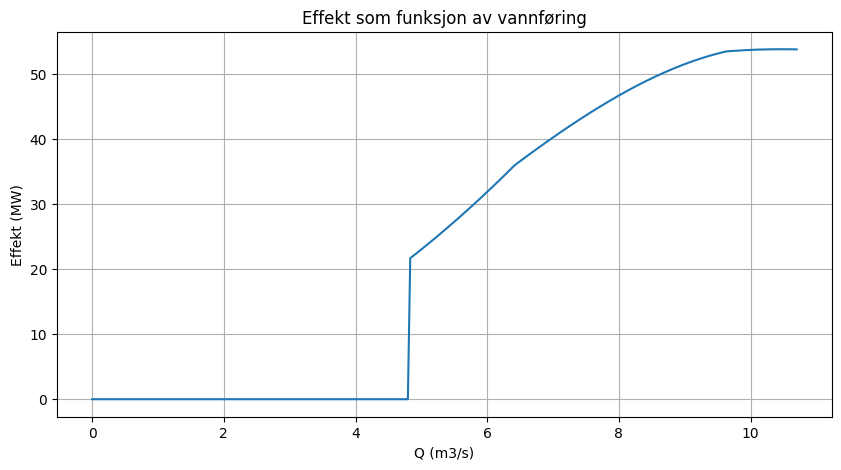

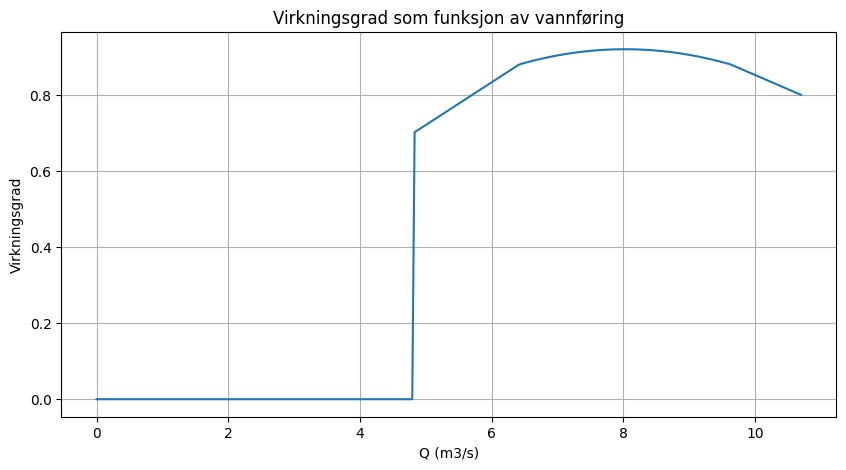

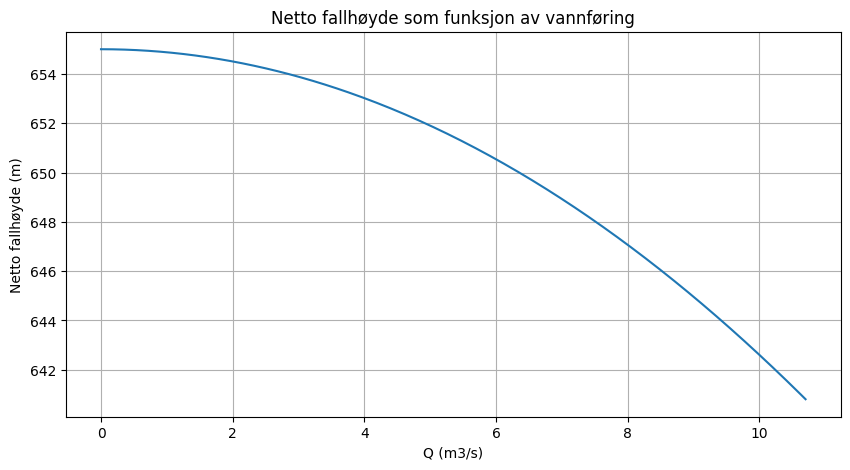

In [3]:
Q_test = np.linspace(0, Q_max, 300)

P_test = []
eta_test = []
Hn_test = []

for Q in Q_test:
    P, eta, Hn = power_MW(Q)
    P_test.append(P)
    eta_test.append(eta)
    Hn_test.append(Hn)

plt.figure(figsize=(10, 5))
plt.plot(Q_test, P_test)
plt.xlabel("Q (m3/s)")
plt.ylabel("Effekt (MW)")
plt.title("Effekt som funksjon av vannføring")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(Q_test, eta_test)
plt.xlabel("Q (m3/s)")
plt.ylabel("Virkningsgrad")
plt.title("Virkningsgrad som funksjon av vannføring")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(Q_test, Hn_test)
plt.xlabel("Q (m3/s)")
plt.ylabel("Netto fallhøyde (m)")
plt.title("Netto fallhøyde som funksjon av vannføring")
plt.grid(True)
plt.show()

In [8]:
def revenue_curve_for_hour(t, q_penalty_coeff=20000.0, water_value_ore_per_m3=50.0):
    Q_test = np.linspace(0, Q_max, 300)
    rev_test = []

    prev_Q = Q_out[t-1] if t > 0 else 0.0

    for Q in Q_test:
        water_use = Q * 3600

        if V[t] - water_use < Vmin:
            rev_test.append(np.nan)
            continue

        Q_min = 5.0
        if Q > 0 and Q < Q_min:
            rev_test.append(np.nan)
            continue

        P, eta, Hn = power_MW(Q)

        if Q > 0 and P < P_min:
            rev_test.append(np.nan)
            continue

        revenue = prices[t] * 1000 * P - water_value_ore_per_m3 * water_use

        penalty_ore = q_penalty_coeff * Q**2
        revenue -= penalty_ore

        rev_test.append(revenue)

    plt.figure(figsize=(10, 5))
    plt.plot(Q_test, rev_test)
    plt.xlabel("Q (m3/s)")
    plt.ylabel("Revenue-score")
    plt.title(f"Revenue som funksjon av Q for time {t}, pris={prices[t]:.2f} øre/kWh")
    plt.grid(True)
    plt.show()

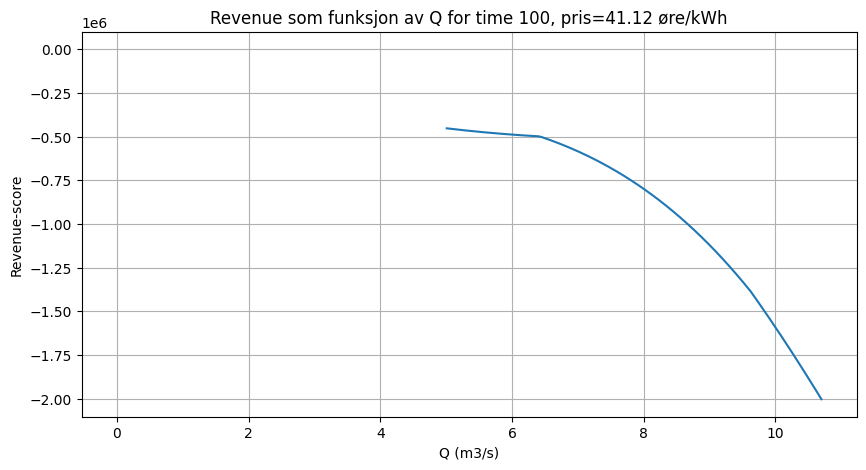

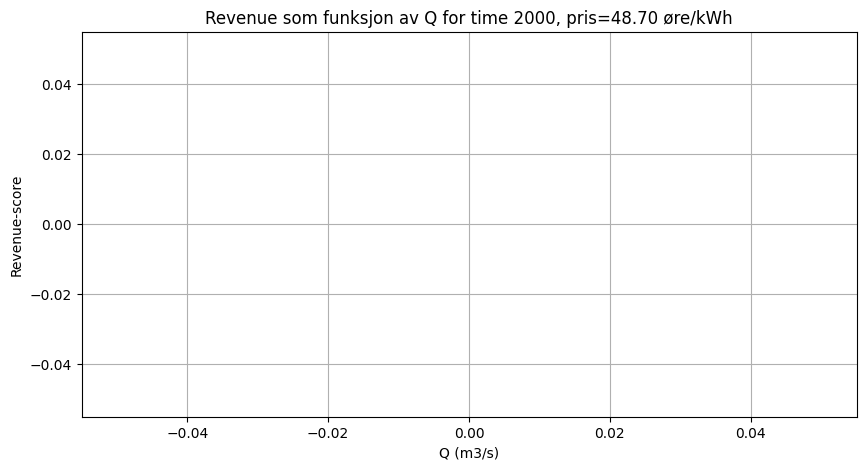

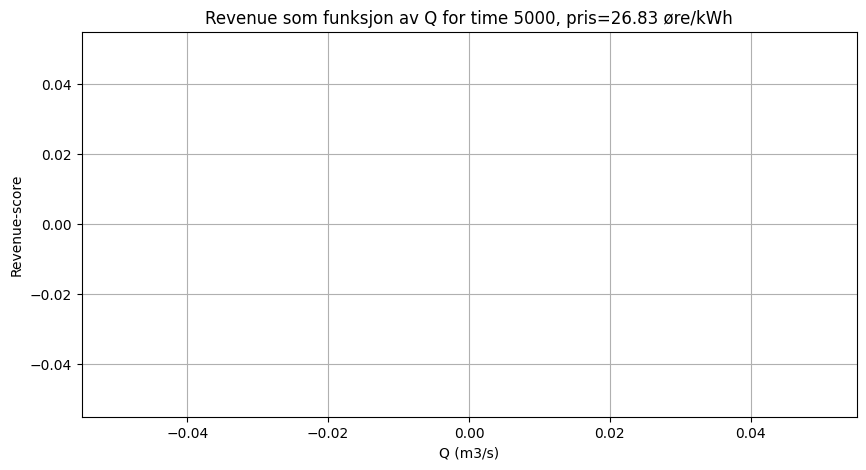

In [5]:
revenue_curve_for_hour(100)
revenue_curve_for_hour(2000)
revenue_curve_for_hour(5000)

In [6]:
Q_test = np.linspace(0, Q_max, 100)
P_test = []

for Q in Q_test:
    P, eta, Hn = power_MW(Q)
    P_test.append(P)

print("Maks effekt i modellen:", max(P_test))

print("V0 =", V0)
print("Vmax =", Vmax)
print("Vmin =", Vmin)

print("Første 10 inflow_hourly:", inflow_hourly[:10])
print("Min inflow:", np.min(inflow_hourly))
print("Max inflow:", np.max(inflow_hourly))

Maks effekt i modellen: 53.83656048681703
V0 = 66149999.99999999
Vmax = 94500000.0
Vmin = 18900000.0
Første 10 inflow_hourly: [10847.98405444 10847.98405444 10847.98405444 10847.98405444
 10847.98405444 10847.98405444 10847.98405444 10847.98405444
 10847.98405444 10847.98405444]
Min inflow: 10800.050005424573
Max inflow: 21599.94999457543
